In [2]:
# Data Exploration

# importing libraries

import numpy as np
import pandas as pd

#Load the dataset

df = pd.read_csv('diabetes.csv')

# find the shape of the dataset

print('Shape of the dataset: ',df.shape)

# columns

print('Columns:\n',df.columns)

# dataset information

print(df.info())

# find the missing values

print('no of missing values:\n',df.isnull().sum())

# find the duplicated records

print('no of duplicated records: ',df.duplicated().sum())

# Statistical summary

print('summary of the datset:\n',df.describe())

Shape of the dataset:  (768, 9)
Columns:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
no of missing values:
 Pregnanci

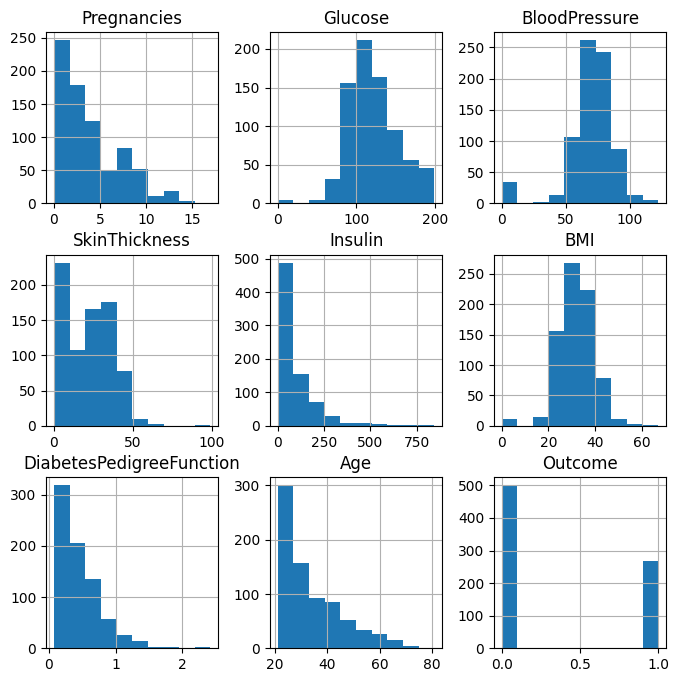

In [3]:
# Exploratory data analysis(EDA)

# find the numerical columns

numerical_col = df.select_dtypes(['int64','float64']).columns
numerical_col

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram


df.hist(figsize = (8,8))
plt.show()

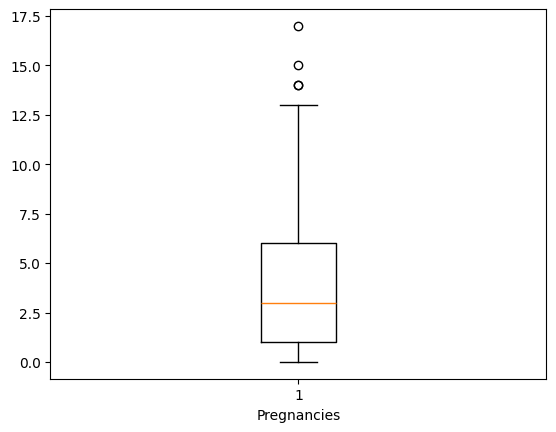

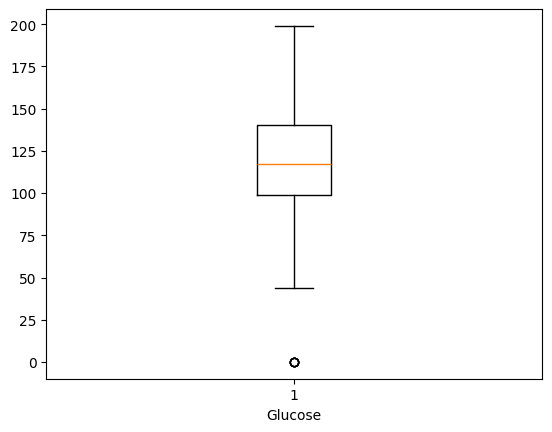

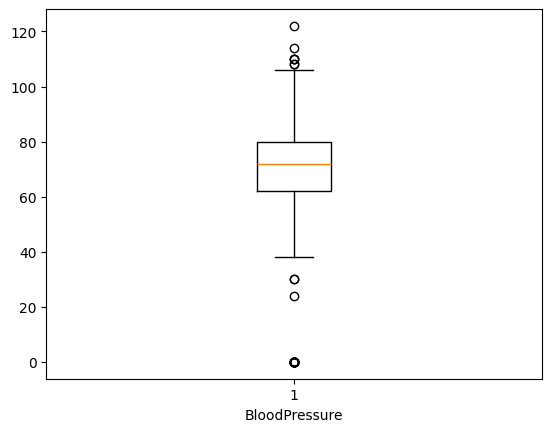

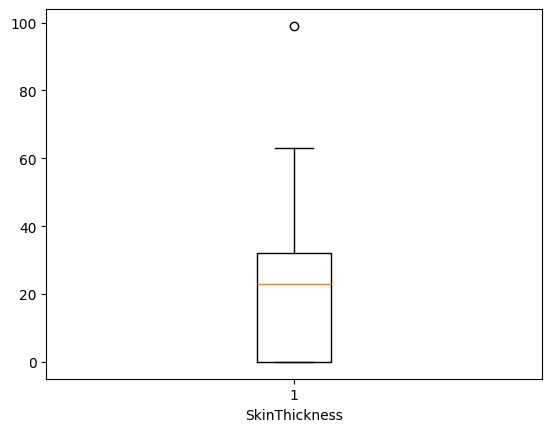

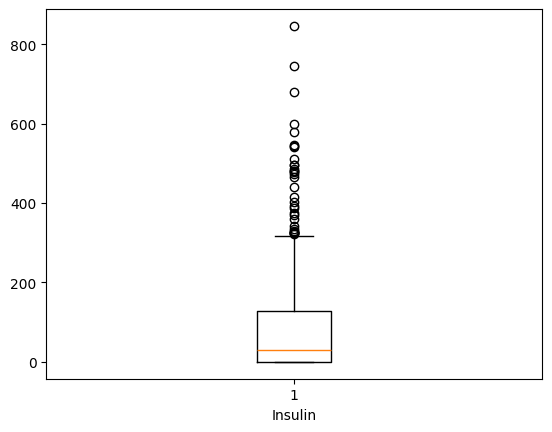

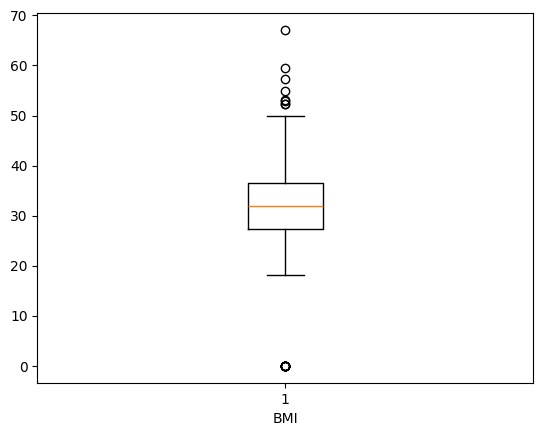

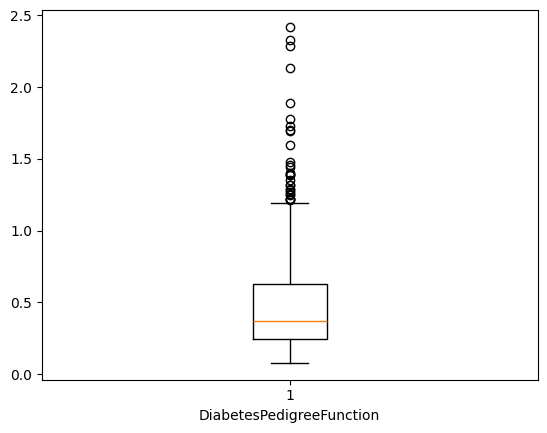

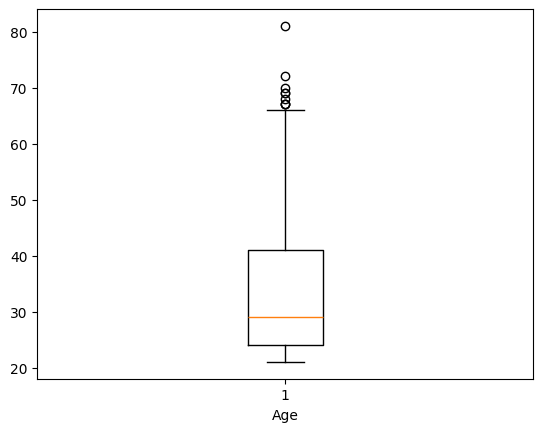

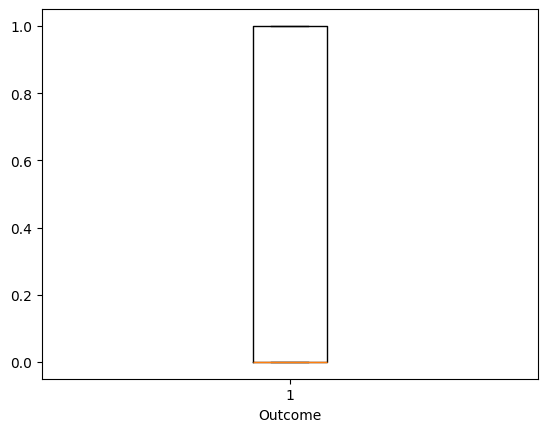

In [4]:
# Boxplot

for col in numerical_col:
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

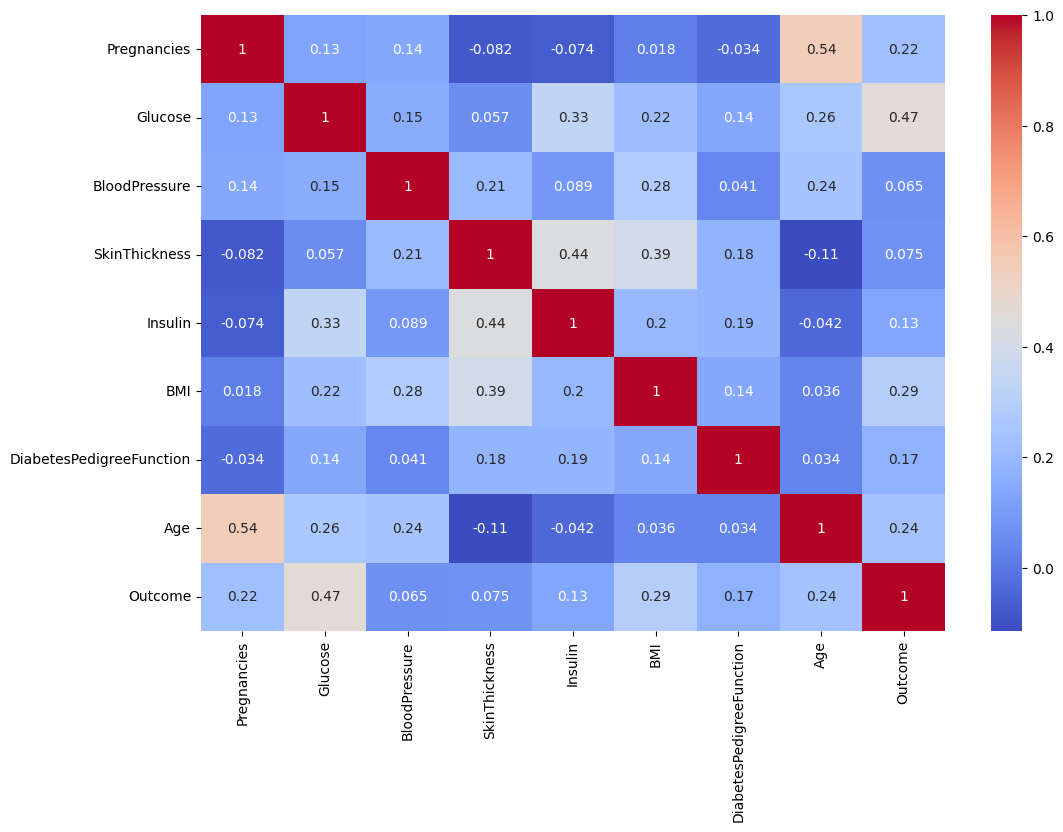

In [5]:
# correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

In [6]:
df.isnull().sum()

x = df.drop('Outcome',axis = 1)
y = df['Outcome']

correlation_matrix = x.corr()
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [8]:
# StandardScaler

SS = StandardScaler()

SS_x = SS.fit_transform(x)
SS_x

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [9]:
x = df.drop('Outcome',axis = 1) # Independent Variable
y = df['Outcome'] # Dependent Variable 

# Spliting the dataset

x_train,x_test,y_train,y_test = train_test_split(SS_x,y,test_size = 0.2,random_state = 42)

# Model Selection

model = LogisticRegression()

# model Fitting

model.fit(x_train,y_train)

import joblib

# Save the trained model and scaler
joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(SS, "scaler.pkl")

print("Model and Scaler saved successfully!")

# Model Prediction

y_pred = model.predict(x_test)

# Evalution

from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,roc_auc_score,confusion_matrix,classification_report

accuracy = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print('Accuracy: ',np.round(accuracy,4))
print('F1-Score: ',np.round(f1,4))
print('Precision: ',np.round(precision,4))
print('Recall: ',np.round(recall,4))
print('ROC-AUC Score: ',np.round(roc_auc,4))
print('confusion matrix: \n',cm)
print('classification report: \n',cr)

Model and Scaler saved successfully!
Accuracy:  0.7532
F1-Score:  0.6607
Precision:  0.6491
Recall:  0.6727
ROC-AUC Score:  0.7354
confusion matrix: 
 [[79 20]
 [18 37]]
classification report: 
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



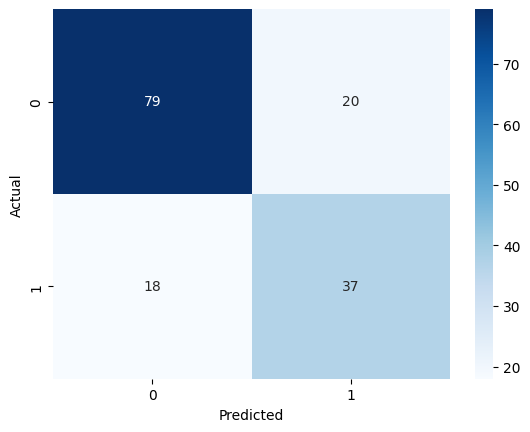

In [10]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

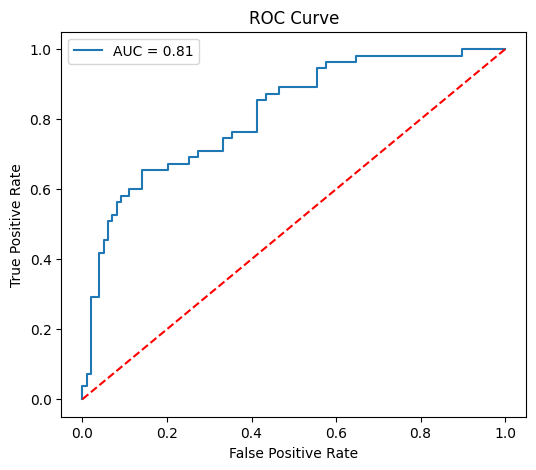

In [11]:
# Probability prediction
y_prob = model.predict_proba(x_test)[:,1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [12]:
coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

print(coef)

                    Feature  Coefficient
0               Pregnancies     0.216242
1                   Glucose     1.069330
2             BloodPressure    -0.258676
3             SkinThickness     0.047203
4                   Insulin    -0.198998
5                       BMI     0.792371
6  DiabetesPedigreeFunction     0.227094
7                       Age     0.430362


Interpretation:

1. Glucose has the highest positive coefficient (1.069), making it the strongest predictor of diabetes.

2. BMI has a positive coefficient (0.792), indicating that higher BMI increases the probability of diabetes.

3. Age has a positive coefficient (0.430), suggesting that older individuals are more likely to develop diabetes.

4. DiabetesPedigreeFunction and Pregnancies also have positive effects.

5. BloodPressure and Insulin have negative coefficients in this fitted model, meaning that after accounting for the other variables, higher values are associated with a lower predicted probability. These coefficients should be interpreted in the context of all predictors together

# Interview Questions


1. What is the difference between precision and recall?


1.Precision measures how many of the instances predicted as positive are actually positive.
2.Recall measures how many of the actual positive cases are correctly identified by the model.''')


2. What is cross-validation, and why is it important in binary classification?

print('''Cross-validation improves confidence that the model will perform well on new, unseen data. In binary classification problems such as diabetes prediction, it is an effective technique for evaluating model performance before deployment.''')

In [13]:
# Deployement Code


# Load model
model = joblib.load("logistic_regression_model.pkl")

# Load scaler 
scaler = joblib.load("scaler.pkl")

print("Enter the following details:")

Pregnancies = float(input("Pregnancies: "))
Glucose = float(input("Glucose: "))
BloodPressure = float(input("Blood Pressure: "))
SkinThickness = float(input("Skin Thickness: "))
Insulin = float(input("Insulin: "))
BMI = float(input("BMI: "))
DiabetesPedigreeFunction = float(input("Diabetes Pedigree Function: "))
Age = float(input("Age: "))

data = pd.DataFrame(
    [[
        Pregnancies,
        Glucose,
        BloodPressure,
        SkinThickness,
        Insulin,
        BMI,
        DiabetesPedigreeFunction,
        Age
    ]],
    columns=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
)

# Scale data
data = scaler.transform(data)

prediction = model.predict(data)

if prediction[0] == 1:
    print("\nPrediction: Diabetic")
else:
    print("\nPrediction: Not Diabetic")

Enter the following details:


Pregnancies:  9
Glucose:  220
Blood Pressure:  120
Skin Thickness:  35
Insulin:  225
BMI:  136
Diabetes Pedigree Function:  1
Age:  20



Prediction: Diabetic
